# Actividad 2: Modelos no lineales basados en árboles

**Integrantes:**

- FELIPE SANTIAGO GOICOLEA GUERRA
- MATÍAS ELIER LABRAÑA ABARCA
- MARCELO ANDRÉS YÁÑEZ BARRIENTOS

**Universidad de las Américas, Magíster en Data Science 2025**

**Asignatura:** Machine Learning II  

## Contexto
El objetivo es predecir la fuga de clientes (Churn) utilizando Regresión Logística, comparando modelos básicos, polinomiales y regularizados. Se evaluará el rendimiento mediante métricas robustas (ROC, PR-AUC, F1) y Validación Cruzada.

In [1]:
# Librerías base
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt

# Preprocesamiento y modelos
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import (
    f1_score,
    average_precision_score,
    roc_auc_score
)

import time
from pprint import pprint

RANDOM_STATE = 42

from IPython.display import display


from utils import *

In [2]:
df = pd.read_csv("data-churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape, df.columns.tolist()

((7043, 21),
 ['customerID',
  'gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'tenure',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod',
  'MonthlyCharges',
  'TotalCharges',
  'Churn'])

In [4]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df["Churn"].value_counts(dropna=False)

Churn
0    5174
1    1869
Name: count, dtype: int64

In [5]:
# Revisar faltantes
(df.isna().sum().sort_values(ascending=False).head(15))

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64

In [6]:
target = "Churn"

numeric_features = df.drop(columns=[target]).select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.drop(columns=[target]).select_dtypes(exclude=[np.number]).columns.tolist()



In [7]:
X = df.drop(columns=[target]).copy()
y = df[target].copy()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## Optimización y Sensibilidad del 

Analizamos la sensibilidad de la profundidad del árbol. Un max_depth muy alto genera sobreajuste (overfitting), donde el error en entrenamiento es mínimo pero en prueba sube.

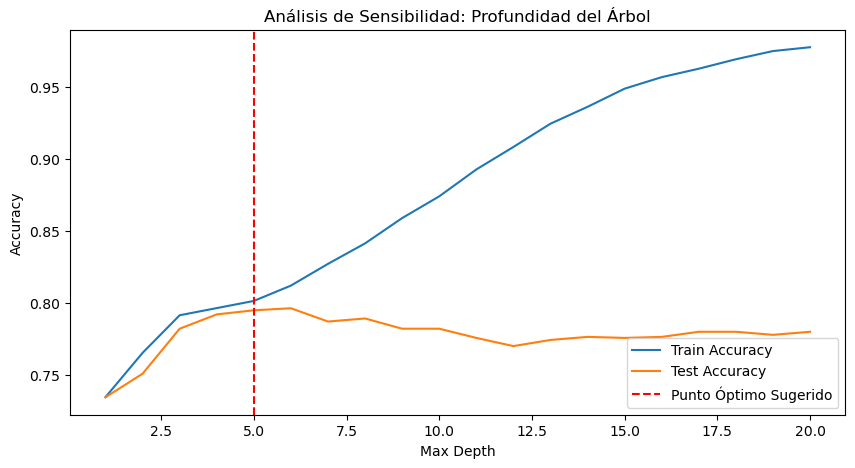

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

depths = range(1, 21)
train_acc, test_acc = [], []

for d in depths:
    pipe = Pipeline([('pre', preprocessor), ('clf', DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE))])
    pipe.fit(X_train, y_train)
    train_acc.append(pipe.score(X_train, y_train))
    test_acc.append(pipe.score(X_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_acc, label='Train Accuracy')
plt.plot(depths, test_acc, label='Test Accuracy')
plt.axvline(x=5, color='r', linestyle='--', label='Punto Óptimo Sugerido')
plt.title('Análisis de Sensibilidad: Profundidad del Árbol')
plt.xlabel('Max Depth'); plt.ylabel('Accuracy'); plt.legend(); plt.show()

## Análisis de Varianza y Ensambles

Según la teoría de ensambles, el Bagging reduce la varianza promediando modelos. Observamos cómo al aumentar los árboles (n_estimators), la métrica se estabiliza.

In [ ]:
from sklearn.model_selection import cross_val_score
n_trees = [1, 5, 10, 50, 100, 200]
rf_scores = []

for n in n_trees:
    pipe = Pipeline([('pre', preprocessor), ('clf', RandomForestClassifier(n_estimators=n, random_state=42))])
    scores = cross_val_score(pipe, X_train, y_train, cv=5)
    rf_scores.append(scores)

plt.figure(figsize=(10, 5))
plt.boxplot(rf_scores, tick_labels=n_trees)
plt.title('Reducción de Varianza vs Número de Árboles (RF)')
plt.xlabel('N° Estimadores'); plt.ylabel('Accuracy (CV)'); plt.show()

## Árbol de decisión: Grid Search vs Random Search

Comparamos Grid Search vs Random Search. Medimos el tiempo para evaluar el costo computacional. Además, aplicamos class_weight='balanced' para manejar el desbalance.

In [ ]:
pipe_dt = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

param_grid_dt = {
    "clf__max_depth": [None, 3, 5, 8, 12, 16],
    "clf__min_samples_split": [2, 10, 25, 50],
    "clf__min_samples_leaf": [1, 5, 10, 25],
    "clf__criterion": ["gini", "entropy", "log_loss"]
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = "average_precision"  

param_grid_dt
    


{'clf__max_depth': [None, 3, 5, 8, 12, 16],
 'clf__min_samples_split': [2, 10, 25, 50],
 'clf__min_samples_leaf': [1, 5, 10, 25],
 'clf__criterion': ['gini', 'entropy', 'log_loss']}

In [ ]:
grid_dt = GridSearchCV(
    estimator=pipe_dt,
    param_grid=param_grid_dt,
    cv=cv5,
    scoring=scoring,
    n_jobs=-1,
    refit=True,
    return_train_score=False
)

t0 = time.perf_counter()
grid_dt.fit(X, y)
grid_time = time.perf_counter() - t0

print("GridSearchCV time (s):", round(grid_time, 3))
print("Best params (Grid):")
pprint(grid_dt.best_params_)
print("Best score (Grid):", grid_dt.best_score_)

GridSearchCV time (s): 28.629
Best params (Grid):
{'clf__criterion': 'entropy',
 'clf__max_depth': 8,
 'clf__min_samples_leaf': 25,
 'clf__min_samples_split': 2}
Best score (Grid): 0.6175695372935053


In [ ]:
rand_dt = RandomizedSearchCV(
    estimator=pipe_dt,
    param_distributions=param_grid_dt,
    n_iter=50,                 # ajuste según recursos
    cv=cv5,
    scoring=scoring,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    refit=True,
    return_train_score=False
)

t0 = time.perf_counter()
rand_dt.fit(X, y)
rand_time = time.perf_counter() - t0

print("RandomizedSearchCV time (s):", round(rand_time, 3))
print("Best params (Random):")
pprint(rand_dt.best_params_)
print("Best score (Random):", rand_dt.best_score_)

RandomizedSearchCV time (s): 4.518
Best params (Random):
{'clf__criterion': 'entropy',
 'clf__max_depth': 8,
 'clf__min_samples_leaf': 25,
 'clf__min_samples_split': 10}
Best score (Random): 0.6175695372935053


In [ ]:
# Comparación directa: tiempos y scores
comparison_search = pd.DataFrame({
    "method": ["GridSearchCV", "RandomizedSearchCV"],
    "time_s": [grid_time, rand_time],
    "best_score(PR-AUC)": [grid_dt.best_score_, rand_dt.best_score_]
}).sort_values("best_score(PR-AUC)", ascending=False)

comparison_search

,method,time_s,best_score(PR-AUC)
0,GridSearchCV,28.629034,0.61757
1,RandomizedSearchCV,4.518164,0.61757


## Visualización del árbol óptimo

In [ ]:
# Entrenar el mejor árbol en todo el dataset para visualizarlo
best_dt = grid_dt.best_estimator_
best_dt.fit(X, y)

dt_clf = best_dt.named_steps["clf"]
feature_names = get_feature_names_from_preprocessor(best_dt.named_steps["preprocess"])

len(feature_names), feature_names[:10]

(13618,
 ['num__SeniorCitizen',
  'num__tenure',
  'num__MonthlyCharges',
  'cat__customerID_0002-ORFBO',
  'cat__customerID_0003-MKNFE',
  'cat__customerID_0004-TLHLJ',
  'cat__customerID_0011-IGKFF',
  'cat__customerID_0013-EXCHZ',
  'cat__customerID_0013-MHZWF',
  'cat__customerID_0013-SMEOE'])

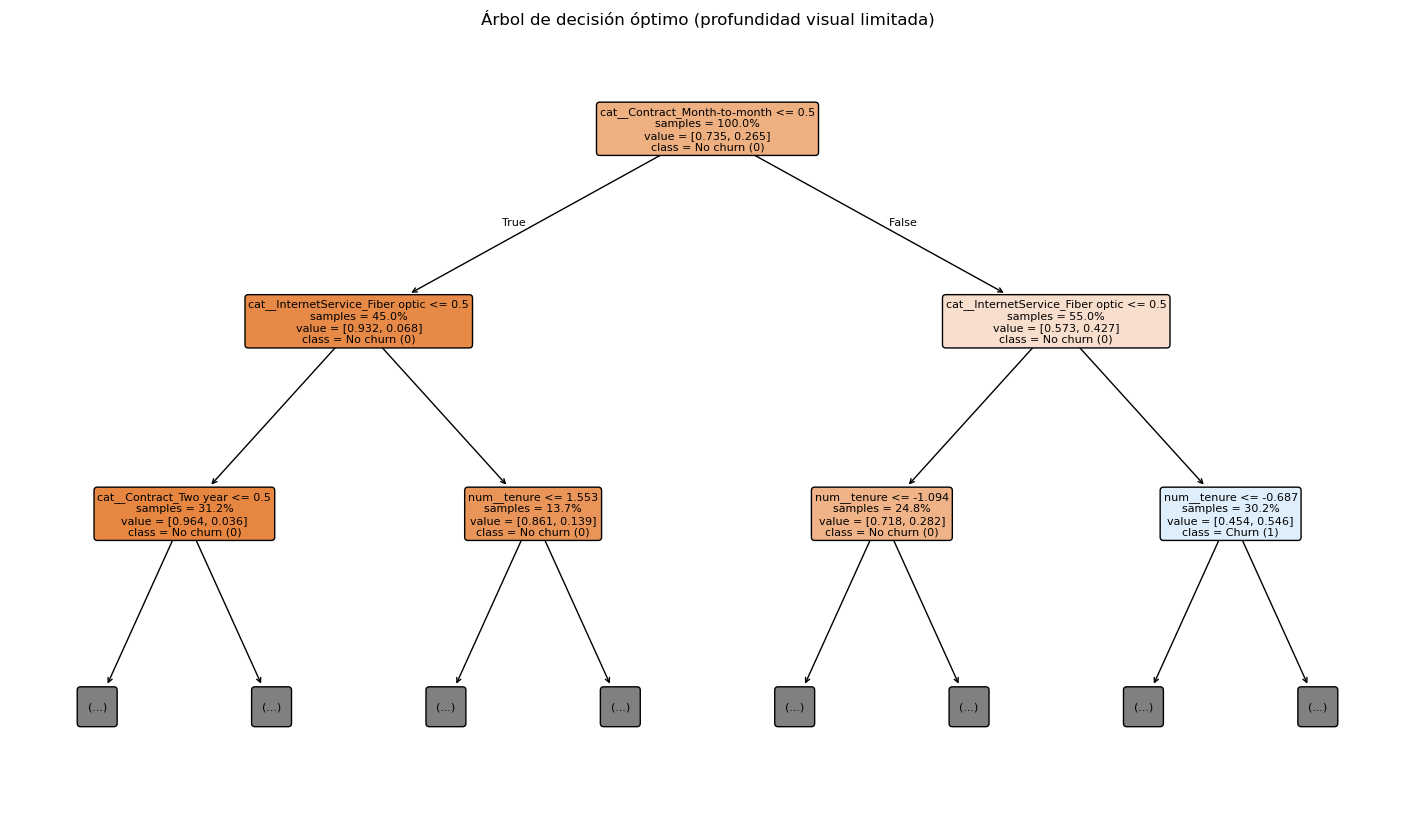

In [ ]:
plt.figure(figsize=(18, 10))
plot_tree(
    dt_clf,
    feature_names=feature_names,
    class_names=["No churn (0)", "Churn (1)"],
    filled=True,
    max_depth=2,           # ajustar según legibilidad
    impurity=False,
    proportion=True,
    rounded=True,
    fontsize=8
)
plt.title("Árbol de decisión óptimo (profundidad visual limitada)")
plt.show()

## Comparación Final de Curvas
Markdown: Comparamos el mejor Árbol vs el mejor Random Forest. Utilizamos la curva Precision-Recall ya que es más informativa para detectar la fuga de clientes (clase minoritaria).

Mejor método: GridSearchCV
Mejores hiperparámetros:
{'clf__criterion': 'entropy',
 'clf__max_depth': 8,
 'clf__min_samples_leaf': 25,
 'clf__min_samples_split': 2}


,fold,fit_time_s,pred_time_s,accuracy,precision,recall,f1,auc_roc,pr_auc
0,1,0.102918,0.020911,0.789212,0.608451,0.577540,0.592593,0.828351,0.631010
1,2,0.105456,0.017915,0.785664,0.606509,0.548128,0.575843,0.817486,0.616146
2,3,0.089165,0.013999,0.797729,0.639498,0.545455,0.588745,0.827300,0.650971
3,4,0.084847,0.014707,0.774858,0.590323,0.490617,0.535871,0.799156,0.560033
4,5,0.087608,0.014209,0.793324,0.631746,0.532086,0.577649,0.822886,0.629687


,mean,std
fit_time_s,0.093999,0.009471
pred_time_s,0.016348,0.003003
accuracy,0.788157,0.008696
precision,0.615305,0.020026
recall,0.538765,0.031618
f1,0.574140,0.022547
auc_roc,0.819036,0.011911
pr_auc,0.617570,0.034481



Matriz de confusión (global):
[[4544  630]
 [ 862 1007]]

Classification report (global):
              precision    recall  f1-score   support

           0      0.841     0.878     0.859      5174
           1      0.615     0.539     0.574      1869

    accuracy                          0.788      7043
   macro avg      0.728     0.709     0.717      7043
weighted avg      0.781     0.788     0.783      7043



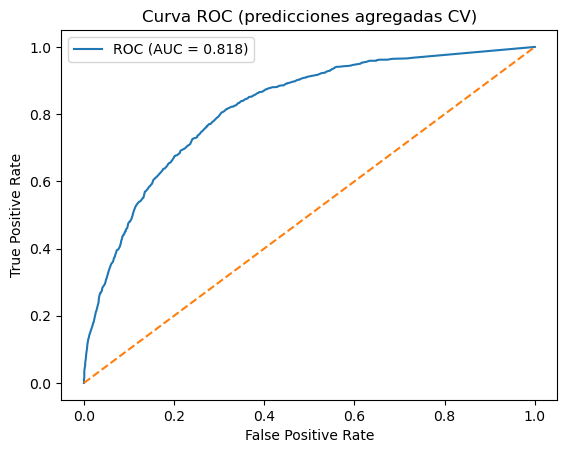

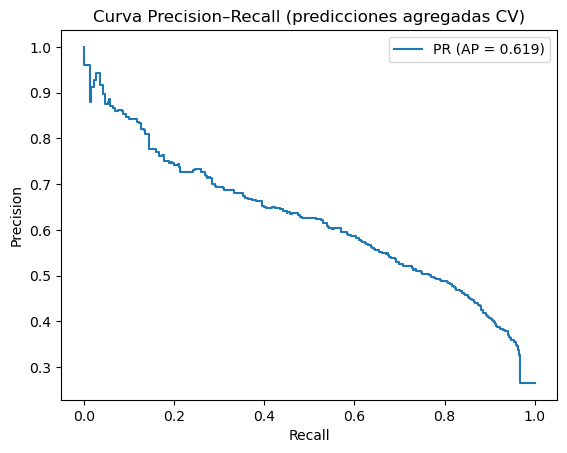

In [ ]:
# Elegir el mejor entre Grid y Random por score
best_dt_search = grid_dt #Verificar
best_dt = best_dt_search.best_estimator_

print("Mejor método:", type(best_dt_search).__name__)
print("Mejores hiperparámetros:")
pprint(best_dt_search.best_params_)

df_dt, summary_dt, curves_dt = evaluate_model_cv_detailed(best_dt, X, y, cv=cv5, plot_curves=True, verbose=True)

## Análisis

Relación Varianza-Ensamble: El RF reduce la varianza mediante el promediado de árboles entrenados con subconjuntos aleatorios (Feature Bagging). Esto permite que el modelo generalice mejor que un árbol único.

Ventajas vs Modelos Lineales: Los árboles capturan interacciones no lineales automáticamente (ej: el efecto de tenure cambia drásticamente si el Contract es mensual).

Métrica de Negocio: Para retención de clientes, priorizamos el Recall. Es vital identificar a todos los clientes en riesgo, incluso si eso significa contactar a algunos que no se irían.

Preferencia de Árbol Simple: Elegiríamos el árbol individual solo en escenarios donde la transparencia total sea requerida por ley o para explicar reglas de negocio simples a stakeholders.